In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import torch
import pycolmap
from PIL import Image
torch.set_default_dtype(torch.float32)

In [2]:
from pathlib import Path

parent_root = Path("/orcd/home/002/yuanxiuw/")                # /parent
gs_root     = parent_root / "guide-3d/gaussian-splatting"
data_root   = parent_root / "kitchen/"

model_dir = parent_root / "kitchen/"
images_dir  = data_root / "images"
sparse_dir  = data_root / "sparse/0"

print(images_dir)   # sanity check
print(images_dir.exists())



/orcd/home/002/yuanxiuw/kitchen/images
True


In [3]:
ply_path  = model_dir / "point_cloud/iteration_7000/point_cloud.ply"
output_dir     = data_root / "renders_3dgs"
output_dir.mkdir(exist_ok=True, parents=True)

In [4]:
recon = pycolmap.Reconstruction(sparse_dir)
images = list(recon.images.values())
images.sort(key=lambda im: im.image_id)  # deterministic order

print(f"Loaded {len(images)} registered images.")

Loaded 279 registered images.


In [5]:
knn_root     = gs_root / "submodules" / "simple-knn"  # top of that repo

# 1) Make simple_knn importable directly from source
sys.path.append(str(knn_root))

# 2) Make 3DGS code importable
sys.path.append(str(gs_root))

print("last sys.path entries:", sys.path[-2:])

import simple_knn
print("simple_knn imported from:", simple_knn.__file__)

last sys.path entries: ['/orcd/home/002/yuanxiuw/guide-3d/gaussian-splatting/submodules/simple-knn', '/orcd/home/002/yuanxiuw/guide-3d/gaussian-splatting']
simple_knn imported from: None


In [6]:
repo_root = Path("gaussian-splatting").resolve()
sys.path.append(str(repo_root))
from gaussian_renderer import render
from scene import Scene, GaussianModel
from scene.cameras import Camera  # or whatever your repo uses

In [7]:
device = "cuda:0"

gaussians = GaussianModel(sh_degree=3)
gaussians.load_ply(str(ply_path)) 
bg = torch.tensor([1.0, 1.0, 1.0], device=device)

In [8]:
import sys, argparse
from pathlib import Path

import torch
import numpy as np
import cv2

repo_root = Path("gaussian-splatting").resolve()
sys.path.append(str(repo_root))

from arguments import ModelParams, PipelineParams
from scene import Scene, GaussianModel
from gaussian_renderer import render

device = "cuda:0"

# EDIT THESE TWO PATHS
source_path = data_root      # contains images/ and sparse/
model_path  = model_dir  # same as --model_path used in training

print("source_path:", source_path)
print("model_path:", model_path)

# --- build parser and args like in train.py ---
parser = argparse.ArgumentParser(description="Inference params")
lp = ModelParams(parser)
pp = PipelineParams(parser)

# minimal argv; all other options take defaults
argv = [
    "--source_path", str(source_path),
    "--model_path",  str(model_path),
    "--images",      "images",
]

args = parser.parse_args(argv)

dataset = lp.extract(args)   # same object they call "dataset" in training()
pipe    = pp.extract(args)

source_path: /orcd/home/002/yuanxiuw/kitchen
model_path: /orcd/home/002/yuanxiuw/kitchen


In [9]:
gaussians = GaussianModel(dataset.sh_degree, optimizer_type="adam")  # optimizer_type only matters for training
scene = Scene(dataset, gaussians, load_iteration=7000, shuffle=False, resolution_scales=[1.0])

# Now scene.gaussians and scene.getTrainCameras() / getTestCameras() are ready
train_cams = scene.getTrainCameras(scale=1.0)   # list of Camera
test_cams  = scene.getTestCameras(scale=1.0)

print("train cams:", len(train_cams), "test cams:", len(test_cams))

Loading trained model at iteration 7000
Reading camera 279/279
Loading Training Cameras
[ INFO ] Encountered quite large input images (>1.6K pixels width), rescaling to 1.6K.
 If this is not desired, please explicitly specify '--resolution/-r' as 1
Loading Test Cameras
train cams: 279 test cams: 0


In [10]:
attrs = ["_xyz", "_features_dc", "_features_rest",
         "_scaling", "_rotation", "_opacity"]

for name in attrs:
    t = getattr(scene.gaussians, name, None)
    if isinstance(t, torch.Tensor) and t.dtype != torch.float32:
        print(f"Converting {name} from {t.dtype} to float32")
        setattr(scene.gaussians, name, t.float())

In [11]:
bg_color = [1, 1, 1] if dataset.white_background else [0, 0, 0]
background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")

In [12]:
import contextlib, io
import torch
import numpy as np

def quiet_predict(model, images_pil, texts_prompt):
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
        return model.predict(images_pil, texts_prompt)

def predict_masks_safe_batch(langsam_model, images_pil, texts_prompt):
    """
    images_pil   : list of PIL images
    texts_prompt : list of strings, same length
    returns      : list of results (one per image), where a result is either
                   the LangSAM result dict or None if prediction failed
    """
    assert len(images_pil) == len(texts_prompt)
    n = len(images_pil)

    # Try one batched call for the whole chunk
    try:
        batch_results = quiet_predict(langsam_model, images_pil, texts_prompt)
        # If success, just return
        return list(batch_results)
    except AssertionError:
        # SAM2 got confused; fall back to per-image calls
        results = []
        for img_pil, txt in zip(images_pil, texts_prompt):
            try:
                single_res = quiet_predict(langsam_model, [img_pil], [txt])
                results.append(single_res[0])   # index 0 from list
            except AssertionError:
                # this particular image failed → no mask
                results.append(None)
            except RuntimeError as e:
                # e.g. OOM or other model errors; also treat as no mask
                results.append(None)
                torch.cuda.empty_cache()
        return results

In [13]:
torch.cuda.empty_cache()
rows = []

In [44]:
from lang_sam import LangSAM
device = "cuda:0"
langsam_model = LangSAM(device=device)

batch_size = 2
masks_by_name = {}

gt_pils  = []
gt_names = []
text_prompt = "blue mat"

for cam in train_cams:
    # cam.original_image: (3, H, W) float in [0,1]
    gt = torch.clamp(cam.original_image.to("cpu"), 0.0, 1.0)   # (3,H,W)

    # to HxWx3 uint8 RGB
    gt_np = (gt.permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)

    gt_pils.append(Image.fromarray(gt_np))   # PIL RGB image
    gt_names.append(cam.image_name)          # keep name to index masks_by_name

for i in range(0, len(gt_pils), batch_size):
    batch_imgs  = gt_pils[i:i+batch_size]
    batch_names = gt_names[i:i+batch_size]
    batch_texts = [text_prompt] * len(batch_imgs)

    batch_results = predict_masks_safe_batch(langsam_model, batch_imgs, batch_texts)

    for name, res in zip(batch_names, batch_results):
        if res is None:
            masks_by_name[name] = None
            continue

        masks = res["masks"]
        if isinstance(masks, torch.Tensor):
            masks_np = masks.cpu().numpy()
        else:
            masks_np = np.asarray(masks)

        if masks_np.shape[0] == 0:
            masks_by_name[name] = None
            continue

        mask = (masks_np[0] > 0.5).astype(np.uint8)
        masks_by_name[name] = mask

    torch.cuda.empty_cache()

One or both local paths not provided. Loading from Hugging Face Hub: IDEA-Research/grounding-dino-base


Loading weights: 100%|███████████████████████████████████████████████████| 1206/1206 [00:00<00:00, 18253.41it/s]


In [45]:
import torch
import cv2
import numpy as np
from utils.loss_utils import l1_loss, ssim
from utils.image_utils import psnr
from lang_sam import LangSAM
from torch.cuda.amp import autocast

try:
    from fused_ssim import fused_ssim
    FUSED_SSIM_AVAILABLE = True
except ImportError:
    FUSED_SSIM_AVAILABLE = False


def render_metrics_frame(cam, gaussians, pipe, background, text_prompt, train_test_exp=False):
    """
    Render gaussians from `cam`, compute metrics vs cam.original_image,
    and return a labeled [GT | render] frame (H, 2W, 3, uint8) plus (L1, SSIM, PSNR).
    """

    # --- render (once) ---

    with torch.no_grad():
        with autocast(enabled=False):
            pkg = render(cam, gaussians, pipe, background,
                     use_trained_exp=train_test_exp)
            img = torch.clamp(pkg["render"], 0.0, 1.0)  # (3,H,W)

    gt = torch.clamp(cam.original_image.to(img.device), 0.0, 1.0)

    # train_test_exp cropping if used
    if train_test_exp:
        img = img[..., img.shape[-1] // 2:]
        gt  = gt[...,  gt.shape[-1] // 2:]

    # alpha mask if present
    if cam.alpha_mask is not None:
        alpha = cam.alpha_mask.to(img.device)
        img = img * alpha
        gt  = gt  * alpha

    gt_np_for_sam  = (gt.detach().cpu().permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
    img_np_for_sam = (img.detach().cpu().permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)

    pil_gt   = Image.fromarray(gt_np_for_sam)
    pil_rend = Image.fromarray(img_np_for_sam)

    device = "cuda:0"
    name = cam.image_name
    mask = masks_by_name.get(cam.image_name, None)
    if mask is None:
        return None, None, None, None
    else:
        mask = (mask > 0).astype(np.uint8)  # ensure 0/1
        gt_np_masked  = apply_mask(gt_np_for_sam,  mask)
        img_np_masked = apply_mask(img_np_for_sam, mask)  # reuse GT mask

    gt  = torch.from_numpy(gt_np_masked).to(img.device).permute(2, 0, 1).float() / 255.0
    img = torch.from_numpy(img_np_masked).to(img.device).permute(2, 0, 1).float() / 255.0
    

    # --- metrics ---
    L1_val = l1_loss(img, gt).mean().double()

    if FUSED_SSIM_AVAILABLE:
        ssim_val = fused_ssim(img.unsqueeze(0), gt.unsqueeze(0)).double()
    else:
        ssim_val = ssim(img, gt).double()

    psnr_val = psnr(img, gt).mean().double()

    mask_bool = mask.astype(bool)
    num_masked = int(mask_bool.sum())
    total_pixels = mask_bool.size

    # --- convert to numpy for visualization ---
    img_vis = img.detach().cpu()   # (3,H,W)
    gt_vis  = gt.detach().cpu()

    if img_vis.ndim == 3 and img_vis.shape[0] == 3:
        img_vis = img_vis.permute(1, 2, 0)  # (H,W,3)
    if gt_vis.ndim == 3 and gt_vis.shape[0] == 3:
        gt_vis = gt_vis.permute(1, 2, 0)

    img_np = (img_vis.numpy() * 255.0).clip(0, 255).astype(np.uint8)
    gt_np  = (gt_vis.numpy()  * 255.0).clip(0, 255).astype(np.uint8)

    rend_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    gt_bgr   = cv2.cvtColor(gt_np,  cv2.COLOR_RGB2BGR)
    
    H, W = cam.image_height, cam.image_width
    rend_bgr = cv2.resize(rend_bgr, (W, H))
    gt_bgr   = cv2.resize(gt_bgr,   (W, H))
    
    frame = cv2.hconcat([gt_bgr, rend_bgr])

    # overlay text *after* concat
    name_text   = cam.image_name
    metric_text = f"SSIM {ssim_val.item():.3f}  PSNR {psnr_val.item():.2f} dB"

    cv2.putText(frame, name_text, (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                (0, 255, 0), 2, cv2.LINE_AA)
    cv2.putText(frame, metric_text, (20, 80),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                (0, 255, 0), 2, cv2.LINE_AA)

    return frame, float(L1_val), float(ssim_val), float(psnr_val), num_masked

In [46]:
def apply_mask(img_rgb: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """
    img_rgb : HxWx3 uint8 (RGB)
    mask    : HxW (0/1 or bool)
    returns : HxWx3 uint8, background set to 0 (black) outside mask
    """
    # ensure mask is boolean and same size
    mask_bool = mask.astype(bool)
    if img_rgb.shape[:2] != mask_bool.shape:
        raise ValueError("img and mask size mismatch")

    out = img_rgb.copy()
    out[~mask_bool] = 0  # or any background color you prefer
    return out

In [47]:
import pandas as pd

# Use resolution from first camera to configure VideoWriter
H0, W0 = train_cams[0].image_height, train_cams[0].image_width
fourcc = cv2.VideoWriter_fourcc(*"MJPG")
out_path = model_path / "comparison_debug_counter.avi"
writer = cv2.VideoWriter(str(out_path), fourcc, 5, (2*W0, H0))
print("writer opened:", writer.isOpened())


for i, cam in enumerate(train_cams):
    frame, L1, ssim_val, psnr_val, total_pixels = render_metrics_frame(
        cam,
        scene.gaussians,
        pipe,
        background,
        text_prompt,
        train_test_exp=dataset.train_test_exp
    )
    if frame is None:
        continue

    rows.append({
    "image_name": cam.image_name,
    "object": text_prompt,
    "L1": L1,
    "SSIM": ssim_val,
    "PSNR_dB": psnr_val,
    "total_pixels": total_pixels,
    })

    # sanity: show pixel stats so we know frame content changes
    #print(f"{i}: {cam.image_name}, mean={frame.mean():.2f}, std={frame.std():.2f}, "
          #f"SSIM={ssim_val:.3f}, PSNR={psnr_val:.2f}")

    writer.write(frame)

writer.release()
print("wrote", out_path)

writer opened: True
wrote /orcd/home/002/yuanxiuw/kitchen/comparison_debug_counter.avi


In [48]:
df = pd.DataFrame(rows)
df.to_pickle("data.pkl")
print(df)

       image_name    object        L1      SSIM    PSNR_dB  total_pixels
0    DSCF0656.JPG   tractor  0.004175  0.975383  33.861767        264391
1    DSCF0657.JPG   tractor  0.003715  0.979243  34.514725        260122
2    DSCF0658.JPG   tractor  0.003412  0.981197  35.477566        265526
3    DSCF0659.JPG   tractor  0.003402  0.980923  36.015808        269035
4    DSCF0660.JPG   tractor  0.003097  0.983315  37.075344        273033
..            ...       ...       ...       ...        ...           ...
832  DSCF0930.JPG  blue mat  0.003890  0.982759  38.132622        253747
833  DSCF0931.JPG  blue mat  0.004072  0.985526  36.113842        199666
834  DSCF0932.JPG  blue mat  0.011366  0.960653  30.812057        449570
835  DSCF0933.JPG  blue mat  0.016435  0.961881  29.437033        624402
836  DSCF0934.JPG  blue mat  0.018293  0.956980  28.950788        693963

[837 rows x 6 columns]


In [19]:
print(L1)
print(ssim_val)
print(psnr_val)

0.0037531901616603136
0.9860437512397766
36.785728454589844


In [33]:
from lang_sam import LangSAM
device = "cuda:0"
langsam_model = LangSAM(device=device)    # or LangSAM(device=device) depending on API

One or both local paths not provided. Loading from Hugging Face Hub: IDEA-Research/grounding-dino-base


Loading weights: 100%|███████████████████████████████████████████████████| 1206/1206 [00:00<00:00, 16149.19it/s]


In [34]:
print(type(langsam_model))
print([m for m in dir(langsam_model) if not m.startswith("_")])

<class 'lang_sam.lang_sam.LangSAM'>
['gdino', 'predict', 'sam', 'sam_type']


In [67]:
img_path = model_path / "images/DSCF5915.JPG"
pil_img = Image.open(str(img_path)).convert("RGB")
text_prompt = "iron bowl"
result = langsam_model.predict([pil_img], [text_prompt])
print(result) 

Predicting 1 masks
Predicted 1 masks
[{'scores': array([0.73411953], dtype=float32), 'boxes': array([[ 94.1623 , 258.37393, 814.2527 , 736.4809 ]], dtype=float32), 'text_labels': ['iron bowl'], 'labels': ['iron bowl'], 'masks': array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]],
      shape=(1, 2076, 3115), dtype=float32), 'mask_scores': array(0.98828125, dtype=float32)}]


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


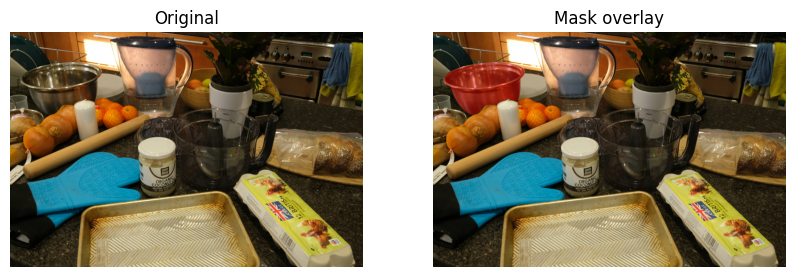

In [68]:
import matplotlib.pyplot as plt
import numpy as np

def show_mask_overlay(img_rgb, mask, alpha=0.4):
    h, w = mask.shape
    img = img_rgb.copy()
    if img.shape[:2] != (h, w):
        img = cv2.resize(img, (w, h))

    # make a red overlay
    overlay = img.copy()
    red = np.array([255, 0, 0], dtype=np.uint8)  # RGB red
    overlay[mask > 0] = red

    blended = (img.astype(np.float32) * (1 - alpha) +
               overlay.astype(np.float32) * alpha).astype(np.uint8)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Mask overlay")
    plt.imshow(blended)
    plt.axis("off")
    plt.show()

# Example:
mask = result[0]["masks"][0]
print(mask)
show_mask_overlay(np.array(pil_img), mask)

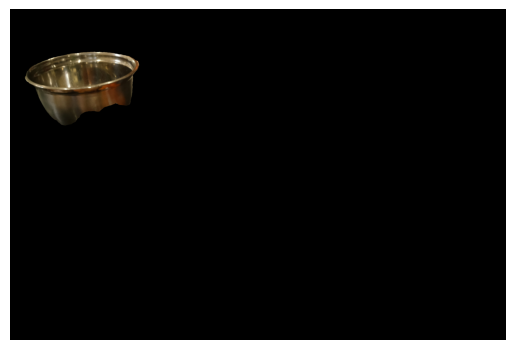

In [70]:
segmented = apply_mask(np.array(pil_img), mask)

plt.imshow(segmented)
plt.axis("off")
plt.show()